In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import pandas as pd


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

transform = transforms.Compose([
    transforms.ToTensor()
])

train_full = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)
test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)
print("Full training dataset size:", len(train_full))
print("Testing dataset size:", len(test_dataset))


train_size = int(0.8 * len(train_full))
val_size = len(train_full) - train_size

train_dataset, val_dataset = random_split(train_full, [train_size, val_size])

print("Training size:", len(train_dataset))
print("Validation size:", len(val_dataset))

batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Using device: cpu
Full training dataset size: 60000
Testing dataset size: 10000
Training size: 48000
Validation size: 12000


In [3]:
class MLP(nn.Module):
    def __init__(self, hidden_neurons=128, activation_name="relu", dropout_rate=0.2):
        super(MLP, self).__init__()

        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(28 * 28, hidden_neurons)

        if activation_name == "relu":
            self.activation = nn.ReLU()
        elif activation_name == "tanh":
            self.activation = nn.Tanh()
        else:
            self.activation = nn.Sigmoid()

        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(hidden_neurons, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.activation(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x

def calculate_accuracy(outputs, labels):
    _, predicted = torch.max(outputs, 1)
    correct = (predicted == labels).sum().item()
    total = labels.size(0)
    return correct / total

In [4]:
def train_model(model, criterion, optimizer, epochs=10):
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_accuracy": [],
        "val_accuracy": []
    }

    for epoch in range(epochs):
        model.train()

        total_train_loss = 0
        total_train_accuracy = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()
            total_train_accuracy += calculate_accuracy(outputs, labels)

        avg_train_loss = total_train_loss / len(train_loader)
        avg_train_accuracy = total_train_accuracy / len(train_loader)

        model.eval()

        total_val_loss = 0
        total_val_accuracy = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                total_val_loss += loss.item()
                total_val_accuracy += calculate_accuracy(outputs, labels)

        avg_val_loss = total_val_loss / len(val_loader)
        avg_val_accuracy = total_val_accuracy / len(val_loader)

        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(avg_val_loss)
        history["train_accuracy"].append(avg_train_accuracy)
        history["val_accuracy"].append(avg_val_accuracy)

        print(
            f"Epoch [{epoch + 1}/{epochs}] "
            f"Train Loss: {avg_train_loss:.4f} "
            f"Val Loss: {avg_val_loss:.4f} "
            f"Train Acc: {avg_train_accuracy:.4f} "
            f"Val Acc: {avg_val_accuracy:.4f}"
        )

    return history


def evaluate_model(model, criterion):
    model.eval()

    total_test_loss = 0
    total_test_accuracy = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_test_loss += loss.item()
            total_test_accuracy += calculate_accuracy(outputs, labels)

    avg_test_loss = total_test_loss / len(test_loader)
    avg_test_accuracy = total_test_accuracy / len(test_loader)

    return avg_test_loss, avg_test_accuracy

In [5]:
experiments = [
    {
        "name": "Experiment 1",
        "activation": "relu",
        "hidden_neurons": 128,
        "learning_rate": 0.001
    },
    {
        "name": "Experiment 2",
        "activation": "tanh",
        "hidden_neurons": 64,
        "learning_rate": 0.01
    }
]

results = []
histories = {}

for exp in experiments:
    print("\n==============================")
    print(exp["name"])
    print("==============================")

    model = MLP(
        hidden_neurons=exp["hidden_neurons"],
        activation_name=exp["activation"],
        dropout_rate=0.2
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=exp["learning_rate"])

    history = train_model(model, criterion, optimizer, epochs=10)

    test_loss, test_accuracy = evaluate_model(model, criterion)

    histories[exp["name"]] = history

    results.append({
        "Experiment": exp["name"],
        "Activation": exp["activation"],
        "Hidden Neurons": exp["hidden_neurons"],
        "Learning Rate": exp["learning_rate"],
        "Final Test Loss": test_loss,
        "Final Test Accuracy": test_accuracy
    })

    print("Test Loss:", test_loss)
    print("Test Accuracy:", test_accuracy)


results_df = pd.DataFrame(results)

print("\nFinal Comparison Table:")
print(results_df)


Experiment 1
Epoch [1/10] Train Loss: 0.4113 Val Loss: 0.2158 Train Acc: 0.8872 Val Acc: 0.9374
Epoch [2/10] Train Loss: 0.1926 Val Loss: 0.1488 Train Acc: 0.9440 Val Acc: 0.9562
Epoch [3/10] Train Loss: 0.1446 Val Loss: 0.1227 Train Acc: 0.9570 Val Acc: 0.9638
Epoch [4/10] Train Loss: 0.1165 Val Loss: 0.1069 Train Acc: 0.9655 Val Acc: 0.9683
Epoch [5/10] Train Loss: 0.0983 Val Loss: 0.0977 Train Acc: 0.9704 Val Acc: 0.9709
Epoch [6/10] Train Loss: 0.0864 Val Loss: 0.0924 Train Acc: 0.9738 Val Acc: 0.9723
Epoch [7/10] Train Loss: 0.0760 Val Loss: 0.0857 Train Acc: 0.9768 Val Acc: 0.9749
Epoch [8/10] Train Loss: 0.0680 Val Loss: 0.0841 Train Acc: 0.9785 Val Acc: 0.9763
Epoch [9/10] Train Loss: 0.0611 Val Loss: 0.0796 Train Acc: 0.9806 Val Acc: 0.9761
Epoch [10/10] Train Loss: 0.0539 Val Loss: 0.0818 Train Acc: 0.9828 Val Acc: 0.9762
Test Loss: 0.07375444948212036
Test Accuracy: 0.9778065286624203

Experiment 2
Epoch [1/10] Train Loss: 0.3258 Val Loss: 0.2114 Train Acc: 0.9010 Val Acc: 

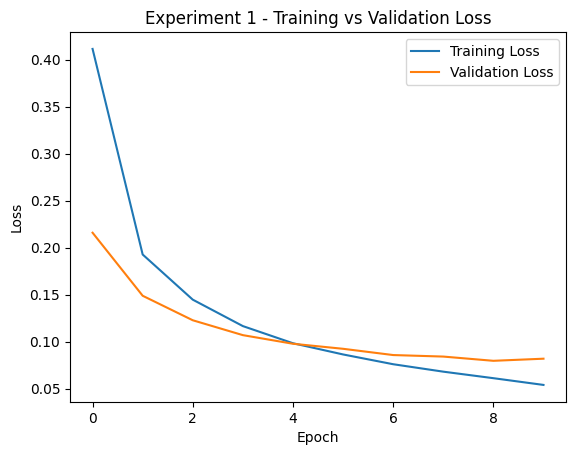

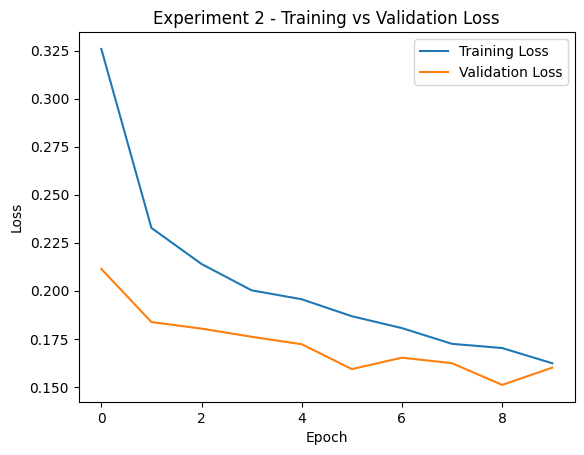

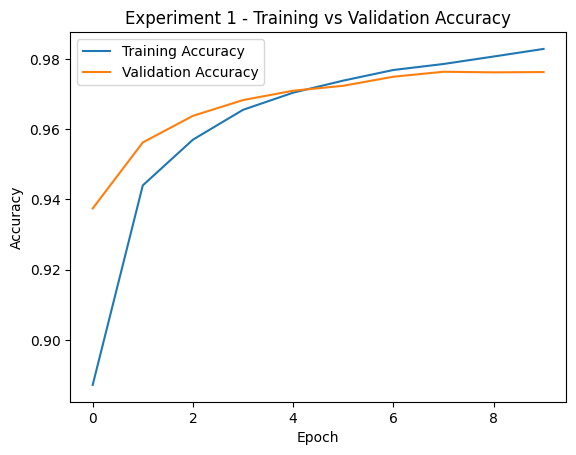

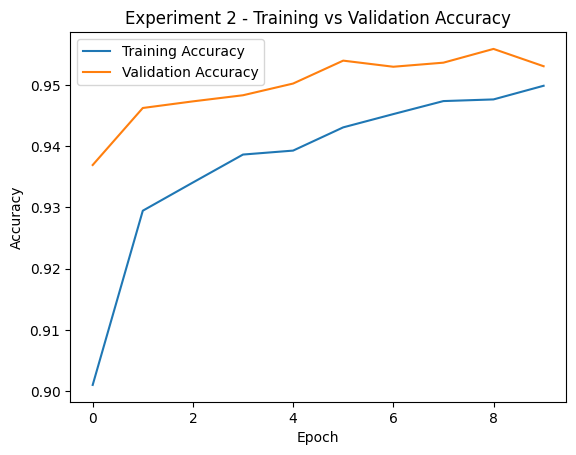

In [6]:
for exp_name, history in histories.items():
    plt.figure()
    plt.plot(history["train_loss"], label="Training Loss")
    plt.plot(history["val_loss"], label="Validation Loss")
    plt.title(f"{exp_name} - Training vs Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()


for exp_name, history in histories.items():
    plt.figure()
    plt.plot(history["train_accuracy"], label="Training Accuracy")
    plt.plot(history["val_accuracy"], label="Validation Accuracy")
    plt.title(f"{exp_name} - Training vs Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()